In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, auc, precision_recall_curve, confusion_matrix
from tensorflow.keras.models import load_model

In [2]:
# Load saved models
gb_model = joblib.load('models/gradientboost_model.pkl')
rf_model = joblib.load('models/randomforest_model.pkl')
autoencoder = load_model('models/dense_autoencoder.h5')
lstm = load_model('models/lstm_autoencoder.h5')

In [3]:
# Load dataset
df_test = pd.read_parquet("data/clean/sensor_clean.pqt")
df_test = df_test.drop(columns=['day_of_week','hour','month'])
df_test = df_test[df_test["timestamp"] >= "2018-06-01"]
X_test = df_test.drop(columns=["timestamp", "machine_status_code"])
y_test = df_test["machine_status_code"].replace({2: 1})  # Convert RECOVERING to anomaly

In [4]:
# Predict with GradientBoost
y_pred_gb = gb_model.predict(X_test)
# Predict with RandomForest
y_pred_rf = rf_model.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/valid

In [5]:
# Autoencoder Predictions
X_test_scaled = (X_test - X_test.min()) / (X_test.max() - X_test.min())  # Min-Max Scaling
X_test_pred = autoencoder.predict(X_test_scaled)
reconstruction_errors = np.mean(np.abs(X_test_scaled - X_test_pred), axis=1)
best_threshold = np.percentile(reconstruction_errors, 95)
y_pred_autoencoder = (reconstruction_errors > best_threshold).astype(int)

4140/4140 [==============================] - 1s 261us/step


In [6]:
# Compute Metrics
def compute_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    prec_vals, rec_vals, _ = precision_recall_curve(y_true, y_pred)
    auc_pr = auc(rec_vals, prec_vals)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return pd.DataFrame({
        "Model": [model_name], "Accuracy": [acc], "Precision": [prec], "Recall": [rec], "F1 Score": [f1],
        "AUC-PR": [auc_pr], "True Negatives": [tn], "False Positives": [fp], "False Negatives": [fn], "True Positives": [tp]
    })

In [7]:
# Evaluate All Models
metrics_gb = compute_metrics(y_test, y_pred_gb, "GradientBoost")
metrics_rf = compute_metrics(y_test, y_pred_rf, "RandomForest")
metrics_autoencoder = compute_metrics(y_test, y_pred_autoencoder, "Autoencoder")
metrics_lstm = compute_metrics(y_test, y_pred_autoencoder, "LSTM")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is depreca

In [8]:
# Combine Results
metrics_df = pd.concat([metrics_gb, metrics_rf, metrics_autoencoder,metrics_lstm], ignore_index=True)
print(metrics_df)

           Model  Accuracy  Precision    Recall  F1 Score    AUC-PR  \
0  GradientBoost  0.998845   0.989571  0.992479  0.991023  0.991266   
1   RandomForest  0.998604   0.983391  0.995064  0.989193  0.989386   
2    Autoencoder  0.909262   0.234903  0.182865  0.205643  0.235126   
3           LSTM  0.909262   0.234903  0.182865  0.205643  0.235126   

   True Negatives  False Positives  False Negatives  True Positives  
0          123882               89               64            8445  
1          123828              143               42            8467  
2          118903             5068             6953            1556  
3          118903             5068             6953            1556  


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


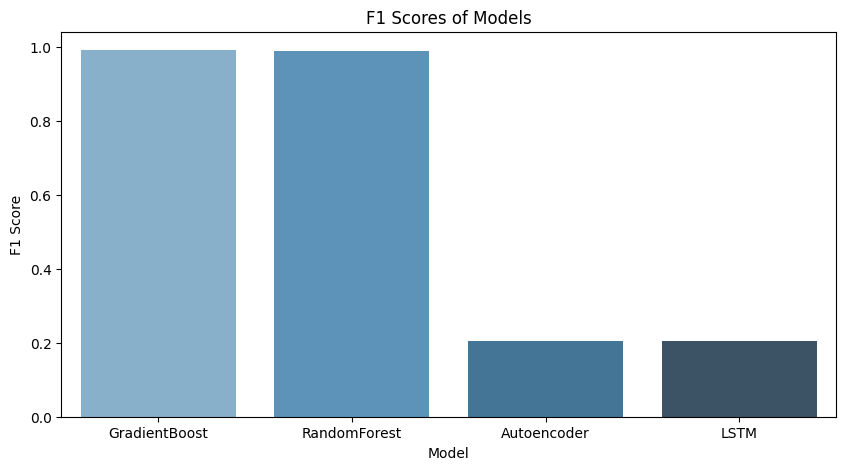

In [9]:
# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="F1 Score", data=metrics_df, palette='Blues_d')
plt.title("F1 Scores of Models")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.show()